# Sinusoidal Embedding

In [ ]:
import math
import torch

from torch import nn

from src.model.embedding import Embedding

T = 1000
n_embd = 512
N = 10000.0

pos = torch.arange(T).unsqueeze(1)
two_i = torch.arange(0, n_embd, 2)
div_term = torch.exp(-math.log(N) * two_i / n_embd)
pos_embeddings = torch.zeros(T, n_embd)
pos_embeddings[:, 0::2] = torch.sin(pos * div_term)
pos_embeddings[:, 1::2] = torch.cos(pos * div_term)

print(pos_embeddings.shape)
print(pos_embeddings.numpy())

torch.Size([1000, 512])
[[ 0.00000000e+00  1.00000000e+00  0.00000000e+00 ...  1.00000000e+00
   0.00000000e+00  1.00000000e+00]
 [ 8.41470957e-01  5.40302336e-01  8.21856201e-01 ...  1.00000000e+00
   1.03663326e-04  1.00000000e+00]
 [ 9.09297407e-01 -4.16146845e-01  9.36414778e-01 ...  1.00000000e+00
   2.07326651e-04  1.00000000e+00]
 ...
 [-8.97967458e-01 -4.40061808e-01  4.26199257e-01 ...  9.94266152e-01
   1.03168443e-01  9.94663894e-01]
 [-8.55473161e-01  5.17847180e-01  9.86278653e-01 ...  9.94254649e-01
   1.03271544e-01  9.94653165e-01]
 [-2.64607519e-02  9.99649823e-01  6.97558343e-01 ...  9.94243145e-01
   1.03374660e-01  9.94642496e-01]]


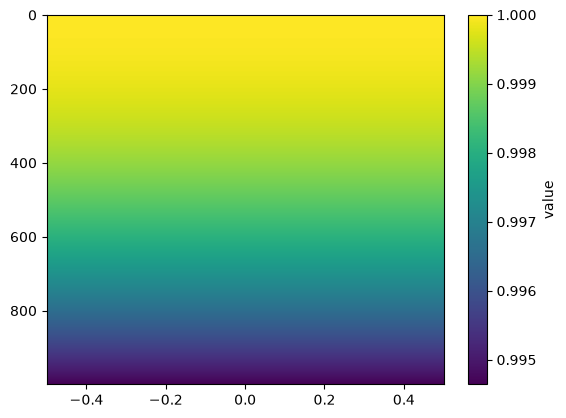

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# data = pos_embeddings[:, :]
data = pos_embeddings[:, 511].unsqueeze(1)

fig, ax = plt.subplots()
im = ax.imshow(data, cmap='viridis', aspect='auto')
fig.colorbar(im, ax=ax, label='value')
plt.show()

In [22]:
import numpy as np
from ml_dtypes import bfloat16

normal_floats = np.array([0.12345], dtype=np.float32)

# Cast to bfloat16
bf16_array = normal_floats.astype(bfloat16)

print(bf16_array)
print("Data Type:", bf16_array.dtype)
print("Memory Size in Bytes:", bf16_array.nbytes)

[0.123535]
Data Type: bfloat16
Memory Size in Bytes: 2
